# Does recovery style affect boat speed? A first-principles model of the rowing stroke

*Christopher Lowans — [06/2026]*

**A first-principles model of the rowing stroke.**

Rowers disagree about how to come up the slide: move the hands and body away quickly then slide slowly to the catch, or move slowly at first and let the boat run, arriving at the catch later. The same rate and effort, differing only in when the rower's weight moves. 

Using a simple physics model built in Python, with its hull drag checked against published measurements for real shells, I find the looser, back-loaded style is faster by around just under half a percent over the 700 m Durham Regatta course. 

The quick hands-away loses not by stopping the boat's run but by creating a forward surge that steep water resistance punishes more than the surge's speed advantage repays; the looser style is faster because it never builds the surge.

*Full derivation, code, and validation below.*

## 1. The question

In Durham College Rowing (DCR) when I attended, the dominant rowing philosophy was to row with fast hands away and body over at the start of the recovery, then a slow, controlled slide to the catch. The idea being that a quicker recovery up the second half of the slide checked the boat i.e., that moving sharply up the slide arrested the run of the hull, whilst fast hands away and bodies over at the start of the recovery (first half of the slide) set up this smooth controlled slide. 

The alternative, most noticeably exhibited by Eric Murray and Hamish Bond, the 'Kiwi Pair' consisted of a looser stroke, with the body's movement toward the catch arriving later in the recovery rather than earlier. In other words, slower hands away and bodies over, and a (relatively) quicker recovery up the second half of the slide. This second style made the most intuitive sense to me; that boat speed was fastest as blades left the water, and it was preferable to not counteract the boat speed at this point.

Very very crudely, if we divide the recovery into two halves of the slide, we have Style 1 as fast then slow, and Style 2 as slow then fast.

This piece sets out to test my old hunch. The two styles are modelled in mechanical terms, identical in stroke
rate, slide length, and propulsive effort, and differ only in *when* during the
recovery the rower's mass moves toward the catch: front-loaded ("fast hands,
slow slide") versus back-loaded ("Kiwi style"). The question is
whether that timing alone changes average boat speed, and if so, by how much,
and under what conditions.

The system's average velocity cannot be moved by the rower's
internal motion, though this does change the centre of mass' position. To change the system's velocity you need an external force i.e., the blades pushing against the water. Any effect of recovery style on velocity must therefore arrive externally through the
way the hull's own speed fluctuates against the non-linear drag force produced by the water.

## 2. Modelling approach

This analysis deliberately begins with a model too simple to answer its own
question, and adds physics layer by layer. Each stage states a hypothesis, tests it, and admits where it falls short; this then leads on to the next stage.

The analysis proceeds in three models of increasing realism:

- **Model 1 — a single mass, no drag.** Establishes the baseline and a useful negative result: with no resistance, only total impulse matters and the shape
  of the stroke is irrelevant.
- **Model 2 — a single mass with quadratic drag.** Introduces the non-linear
  resistance that makes the recovery matter, and produces a realistic
  maximum boat speed.
- **Model 3 — two coupled masses (hull and rower) with drag on the hull.**
  Separates the rower's mass from the boat's, which is the minimum structure
  required to distinguish the two recovery styles, and quantifies the result.

Model parameters are anchored to published experimental data where possible,
in particular the hull drag coefficient is checked against measured values for
real racing shells, and the headline finding is expressed over the Durham Regatta course length in terms of boat lengths and seconds.

## 3. Model 1 — a single mass, no drag

The simplest possible model treats the entire system, hull and rower,
as a single mass, driven forward by a force during the drive and left to run
during the recovery with no resistance. The drive force is taken as
a smooth half-sine pulse: zero at the catch, peak mid-drive, zero at the finish.
The recovery applies no force at all. The boat starts from rest, and we integrate
the resulting acceleration to track its velocity over several strokes.

Hypothesis: with no drag, nothing ever slows the boat, so its speed can only increase stroke on stroke. The shape of the drive pulse should not matter. With no resistance, the change in velocity over a stroke depends only on the total impulse i.e., the area under the force curve and not how that force is applied over time. Two  different drive profiles with the same area should produce identical final speeds.

Final velocity after 5 strokes: 8.913 m/s


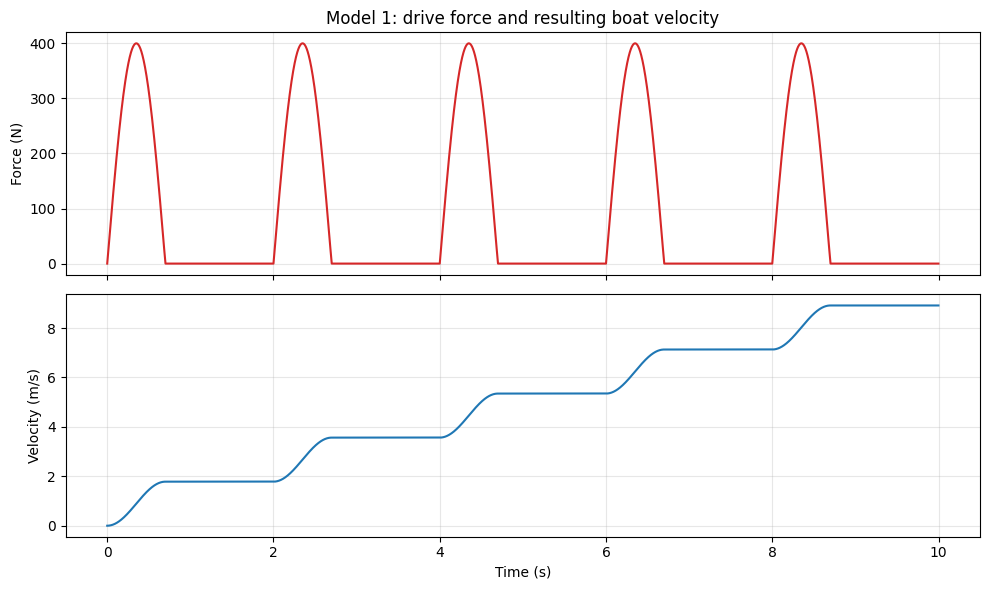

In [11]:
# Model 1: drag-free, single-mass rowing boat
# Result we expect: without drag, only total impulse matters,
# so stroke shape is invisible to final speed.
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
m_total = 100.0      # combined mass of boat + rower(s), kg
F_max   = 400.0      # peak drive force, N
t_drive    = 0.7     # drive phase duration, s
t_recovery = 1.3     # recovery phase duration, s
t_stroke   = t_drive + t_recovery   # one full stroke, s
dt        = 0.001    # time step, s
n_strokes = 5        # number of strokes

total_time = n_strokes * t_stroke
times = np.arange(0, total_time, dt)
forces     = np.zeros_like(times)
velocities = np.zeros_like(times)

velocity = 0.0   # start from rest
for i, t in enumerate(times):
    t_in_stroke = t % t_stroke
    if t_in_stroke < t_drive:
        force = F_max * np.sin(np.pi * t_in_stroke / t_drive)
    else:
        force = 0.0
    acceleration = force / m_total
    velocity = velocity + acceleration * dt
    forces[i]     = force
    velocities[i] = velocity

print(f"Final velocity after {n_strokes} strokes: {velocity:.3f} m/s")

# --- Plot ---
fig, (ax_force, ax_vel) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_force.plot(times, forces, color="tab:red")
ax_force.set_ylabel("Force (N)")
ax_force.set_title("Model 1: drive force and resulting boat velocity")
ax_force.grid(True, alpha=0.3)
ax_vel.plot(times, velocities, color="tab:blue")
ax_vel.set_ylabel("Velocity (m/s)")
ax_vel.set_xlabel("Time (s)")
ax_vel.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The result confirms the prediction. Velocity climbs with each stroke, then holds flat through each recovery, as with no drag there is nothing to reduce the speed. The boat never slows, and the final speed is determined by the accumulated impulse.

This is a useful negative result establishing in a
frictionless world, stroke style is irrelevant by construction. Any two recoveries, no matter the shape, leave the boat in the same place. Whatever makes
recovery style matter then is absent from this model. It must matter when we introduce resistance. That is the motivation for Model 2.

## 4. Model 2 — a single mass with quadratic drag

Model 1 can't answer the question, so the next step adds
resistance. The drive and recovery are unchanged and the only
addition is a drag force opposing motion, taken to grow with the square of speed,
as is standard for a hull at racing pace where form drag dominates. The system is
still a single mass with the rower and hull lumped together so this model still cannot distinguish recovery styles. The point of this model is to establish that drag produces realistic behaviour, and to find the point at which recovery first
begins to matter.

Hypothesis: with drag opposing motion, the boat can no longer accelerate without
limit. Each stroke the drive and drag oppose each other; as speed rises,
drag rises faster, until the two balance at a roughly steady speed. The recovery should no longer be flat. With no drive to sustain it, the hull should now lose speed during each recovery, the first time in this work that anything happens between drives.

Final velocity: 4.880 m/s
Peak velocity:  6.060 m/s


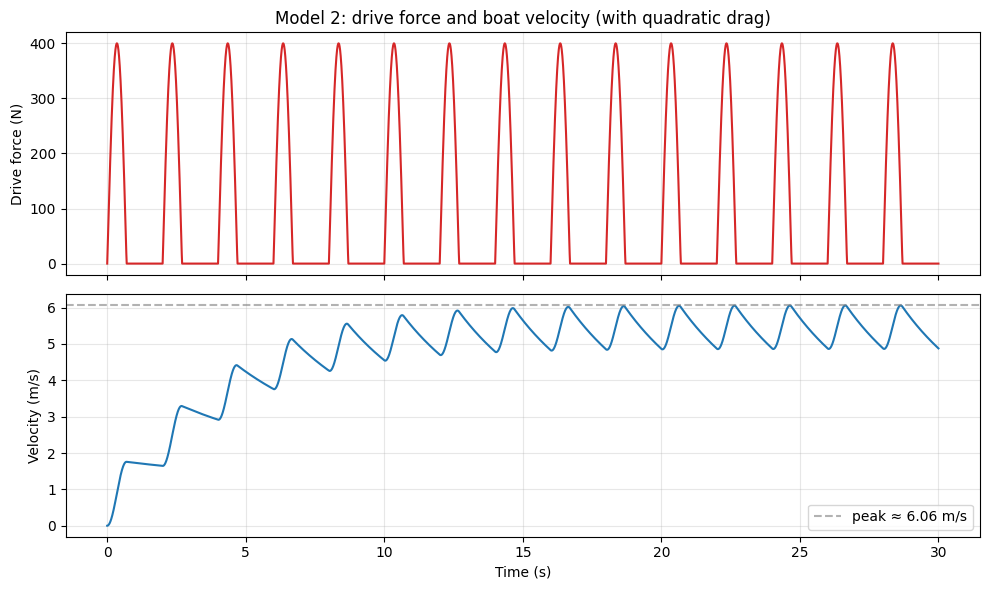

In [12]:
# --- Model 2 simulation: drive force minus quadratic drag ---
# --- Parameters (same drive as Model 1, plus drag) ---
m_total = 100.0      # combined mass, kg
F_max   = 400.0      # peak drive force, N
k_drag  = 3.0        # drag coefficient (N per (m/s)^2) — NEW

t_drive    = 0.7     # drive phase, s
t_recovery = 1.3     # recovery phase, s
t_stroke   = t_drive + t_recovery
dt         = 0.001   # time step, s
n_strokes  = 15      # more strokes now, to see the speed plateau — NEW

total_time = n_strokes * t_stroke
times = np.arange(0, total_time, dt)
forces_drive = np.zeros_like(times)   # drive force alone (for the plot)
velocities   = np.zeros_like(times)

velocity = 0.0   # start from rest
for i, t in enumerate(times):
    t_in_stroke = t % t_stroke

    # Drive force: same sine pulse as Model 1
    if t_in_stroke < t_drive:
        drive = F_max * np.sin(np.pi * t_in_stroke / t_drive)
    else:
        drive = 0.0

    # Drag force: opposes motion, grows with speed squared 
    drag = -k_drag * velocity * abs(velocity)

    # Net force, then integrate
    net_force    = drive + drag
    acceleration = net_force / m_total
    velocity     = velocity + acceleration * dt

    forces_drive[i] = drive
    velocities[i]   = velocity

print(f"Final velocity: {velocity:.3f} m/s")
print(f"Peak velocity:  {velocities.max():.3f} m/s")


#  visualise drive force and velocity (with drag) ---
fig, (ax_force, ax_vel) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax_force.plot(times, forces_drive, color="tab:red")
ax_force.set_ylabel("Drive force (N)")
ax_force.set_title("Model 2: drive force and boat velocity (with quadratic drag)")
ax_force.grid(True, alpha=0.3)

ax_vel.plot(times, velocities, color="tab:blue")
ax_vel.axhline(velocities.max(), color="grey", linestyle="--", alpha=0.6,
               label=f"peak ≈ {velocities.max():.2f} m/s")
ax_vel.set_ylabel("Velocity (m/s)")
ax_vel.set_xlabel("Time (s)")
ax_vel.grid(True, alpha=0.3)
ax_vel.legend(loc="lower right")

plt.tight_layout()
plt.show()

The result behaves as expected. Velocity no longer climbs indefinitely: it
rises through the early strokes, then levels off at a steady maximum where the
drive impulse per stroke is cancelled by the drag loss. The recovery
sections, flat in Model 1, now sag downward. The drag coefficient is anchored to experimental measurements for real racing shells (see §6), and the resulting maximum speed is realistic for the boat class modelled.

This model is the first evidence that what happens during the
recovery can affect the boat. But this model still cannot tell the two
styles apart: with rower and hull treated as one mass, there is no rower moving
within the boat to shape the recovery differently. To capture that the masses are split in Model 3.


## 5. Model 3 — two coupled masses, drag on the hull

The single mass is separated into a hull
and a rower, free to move relative to one another, and 
drag is applied to the hull's speed, not to the speed of the combined centre of
mass. This  allows recovery style to matter. The rower's movement within the boat cannot change the system's average
velocity (§1). If drag acted on the centre of mass, the two styles would be
identical. Drag, however, acts on
the hull, whose speed surges and checks as the rower slides which is when style matters.

The two styles as modelled differ only in when the rower's mass moves
sternward during the recovery: front-loaded ("fast hands, slow slide") versus
back-loaded ("Kiwi style"). Stroke rate, slide length, and
propulsive impulse are held constant across both styles, so any difference in average boat speed can be solely attributed to recovery shape.

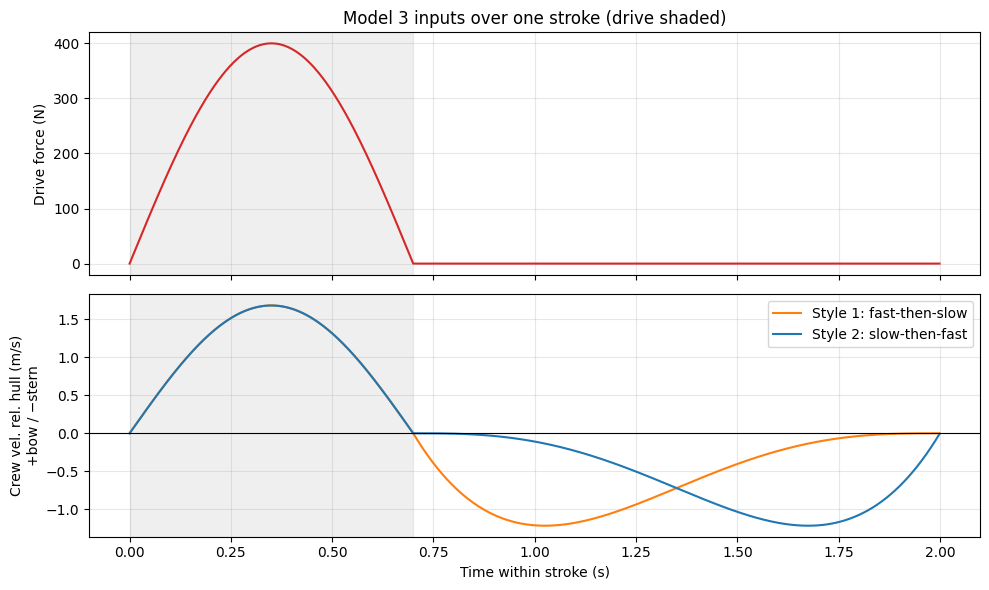

Style 1: drive +0.750 m, recovery -0.750 m
Style 2: drive +0.750 m, recovery -0.750 m


In [13]:
# ============================================================
# Model 3: two-body (hull + crew), drag acts on HULL velocity.
# Question: at fixed impulse, rate, and slide length, does the
# SHAPE of the recovery (style 1 vs style 2) change mean speed?
# Convention: positive = bow (forward). Crew slides bowward in
# the drive (u>0), sternward in recovery (u<0).
# ============================================================

# --- Masses (Dudhia: crew ~80% of total) ---
m_crew  = 80.0
m_hull  = 20.0
M_total = m_crew + m_hull
mass_ratio = m_crew / M_total      # 0.8 — the coupling strength

# --- Drive force, timing, drag (same lineage as Models 1-2) ---
F_max      = 400.0
t_drive    = 0.7
t_recovery = 1.3
t_stroke   = t_drive + t_recovery
dt         = 0.001
n_strokes  = 20
a_drag     = 3.0                   # validated single-sculler value
L_slide    = 0.75                  # crew travel relative to hull, m

# --- Build templates over one stroke ---
t_one = np.arange(0, t_stroke, dt)

# Drive force: sine pulse in the drive, zero in recovery
F_template = np.where(t_one < t_drive,
                      F_max * np.sin(np.pi * t_one / t_drive), 0.0)

def crew_velocity_template(p, q):
    """Crew velocity relative to hull over one stroke.
    Drive = bowward half-sine (+L_slide). Recovery = sternward
    hump skewed by (p,q), normalised to exactly -L_slide."""
    u = np.zeros_like(t_one)
    drive = t_one < t_drive
    rec   = ~drive

    ds = np.sin(np.pi * t_one[drive] / t_drive)
    u[drive] = (L_slide / (ds.sum() * dt)) * ds          # +L_slide

    x  = (t_one[rec] - t_drive) / t_recovery             # 0..1
    rs = x**(p-1) * (1 - x)**(q-1)                        # skew shape
    u[rec] = -(L_slide / (rs.sum() * dt)) * rs           # -L_slide
    return u

# The TWO styles differ only in recovery shape:
u_style1 = crew_velocity_template(2, 4)   # front-loaded: fast-then-slow
u_style2 = crew_velocity_template(4, 2)   # back-loaded:  slow-then-fast

# --- Verify inputs before simulating ---
fig, (axF, axU) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axF.plot(t_one, F_template, color="tab:red")
axF.axvspan(0, t_drive, color="grey", alpha=0.12)
axF.set_ylabel("Drive force (N)"); axF.grid(True, alpha=0.3)
axF.set_title("Model 3 inputs over one stroke (drive shaded)")

axU.plot(t_one, u_style1, color="tab:orange", label="Style 1: fast-then-slow")
axU.plot(t_one, u_style2, color="tab:blue",   label="Style 2: slow-then-fast")
axU.axhline(0, color="black", lw=0.8)
axU.axvspan(0, t_drive, color="grey", alpha=0.12)
axU.set_ylabel("Crew vel. rel. hull (m/s)\n+bow / −stern")
axU.set_xlabel("Time within stroke (s)")
axU.legend(loc="upper right"); axU.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Sanity: both styles must move the same slide length each phase
for name, u in [("Style 1", u_style1), ("Style 2", u_style2)]:
    print(f"{name}: drive {(u[t_one<t_drive].sum()*dt):+.3f} m, "
          f"recovery {(u[t_one>=t_drive].sum()*dt):+.3f} m")

In [14]:
# --- Model 3, Cell 2: two-body engine. Drag acts on the HULL. ---
def simulate(u_template, n_strokes=n_strokes):
    """Run the two-body model for a given recovery style.
    Returns time, hull velocity, and COM velocity arrays."""
    # Tile the one-stroke templates out to n_strokes
    F = np.tile(F_template, n_strokes)
    u = np.tile(u_template, n_strokes)
    times = np.arange(0, len(F)) * dt

    v_cm   = 0.0                      # centre-of-mass velocity
    v_hull = np.zeros_like(times)     # what drag actually sees
    v_com  = np.zeros_like(times)

    for i in range(len(times)):
        # Hull velocity from momentum coupling (the heart of it):
        vh = v_cm - mass_ratio * u[i]

        # Drag acts on the HULL speed, not the COM:
        drag = -a_drag * vh * abs(vh)

        # External forces (drive + drag) move the WHOLE system COM:
        net = F[i] + drag
        v_cm = v_cm + (net / M_total) * dt

        v_hull[i] = vh
        v_com[i]  = v_cm
    return times, v_hull, v_com

# Run both styles
t1, vh1, vc1 = simulate(u_style1)
t2, vh2, vc2 = simulate(u_style2)

# Compare mean HULL speed over the final stroke (steady state)
last = slice(-len(t_one), None)
mean1 = vh1[last].mean()
mean2 = vh2[last].mean()

print(f"Style 1 (fast-then-slow): mean hull speed = {mean1:.4f} m/s")
print(f"Style 2 (slow-then-fast): mean hull speed = {mean2:.4f} m/s")
print(f"Difference: {(mean2-mean1):+.4f} m/s "
      f"({100*(mean2-mean1)/mean1:+.2f}%)")

Style 1 (fast-then-slow): mean hull speed = 5.3779 m/s
Style 2 (slow-then-fast): mean hull speed = 5.3987 m/s
Difference: +0.0208 m/s (+0.39%)


The result is that the two styles do produce different mean hull speeds, and the
back-loaded style, i.e., the Kiwi Pair's is  faster, here by 0.39%. What's not clear yet is why this style is quicker.

My hypothesis before modelling this was that rowing Kiwi Pair style allows the boat to cruise at maximum velocity for longer. That somehow by throwing the hands forward and pushing the system centre of mass sternwards, this would decelerate the boat - I never really have found Newton's 3rd law that intuitive.

                         Style 1 (front)   Style 2 (back)
  mean hull speed (m/s)       5.3779         5.3987
  variance of hull speed     0.78648        0.56245
  mean of v^2 (drag ~)       29.7086        29.7086

  Style 2 has HIGHER mean-of-v^2 -> more drag loss
  Style 2 min speed: 3.887 vs Style 1 min: 3.911  (the catch trough)
  Style 2 max speed: 6.066 vs Style 1 max: 6.706  (the peak)


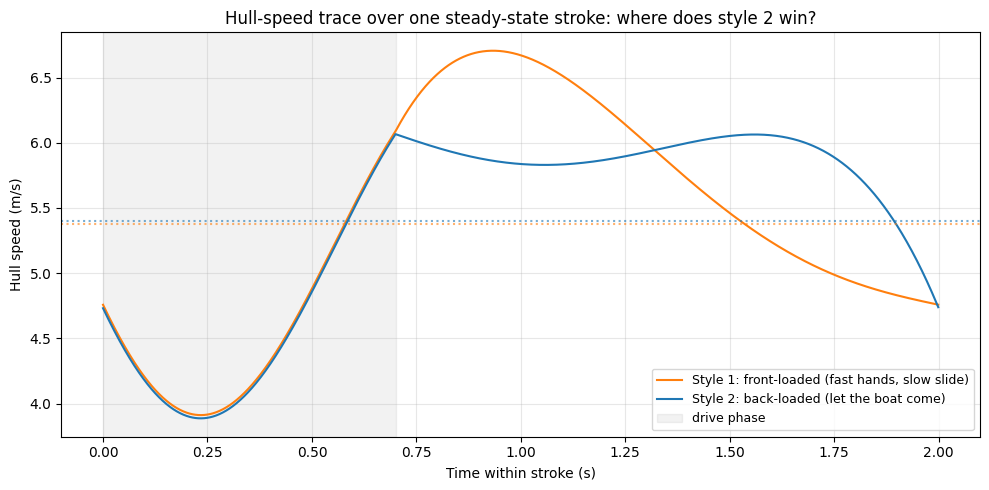

In [15]:
# --- Diagnostic: why is style 2 faster? Compare the hull-speed traces ---
# We extract one steady-state stroke from each style and compare:
#   (a) the shape of the hull-speed trace (variance vs "time near peak")
#   (b) mean speed, variance, and mean-of-v^2 (what actually sets drag loss)

t1, vh1, vc1 = simulate(u_style1)   # front-loaded (style 1)
t2, vh2, vc2 = simulate(u_style2)   # back-loaded  (style 2)

# Take the final (steady-state) stroke from each
n_one = len(t_one)
s1 = vh1[-n_one:]          # style 1 hull speed over last stroke
s2 = vh2[-n_one:]          # style 2 hull speed over last stroke
tt = np.arange(n_one) * dt # time within the stroke

# The three numbers that decide the mechanism
def stats(v):
    return v.mean(), v.var(), (v**2).mean()   # mean, variance, mean-of-v^2

m1, var1, msq1 = stats(s1)
m2, var2, msq2 = stats(s2)

print("                         Style 1 (front)   Style 2 (back)")
print(f"  mean hull speed (m/s)   {m1:10.4f}     {m2:10.4f}")
print(f"  variance of hull speed  {var1:10.5f}     {var2:10.5f}")
print(f"  mean of v^2 (drag ~)    {msq1:10.4f}     {msq2:10.4f}")
print(f"\n  Style 2 has {'LOWER' if msq2 < msq1 else 'HIGHER'} mean-of-v^2 "
      f"-> {'less' if msq2 < msq1 else 'more'} drag loss")
print(f"  Style 2 min speed: {s2.min():.3f} vs Style 1 min: {s1.min():.3f}  (the catch trough)")
print(f"  Style 2 max speed: {s2.max():.3f} vs Style 1 max: {s1.max():.3f}  (the peak)")

# The picture that settles it
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tt, s1, color="tab:orange", label="Style 1: front-loaded (fast hands, slow slide)")
ax.plot(tt, s2, color="tab:blue",   label="Style 2: back-loaded (let the boat come)")
ax.axhline(m1, color="tab:orange", ls=":", alpha=0.6)
ax.axhline(m2, color="tab:blue",   ls=":", alpha=0.6)
ax.axvspan(0, t_drive, color="grey", alpha=0.10, label="drive phase")
ax.set_xlabel("Time within stroke (s)")
ax.set_ylabel("Hull speed (m/s)")
ax.set_title("Hull-speed trace over one steady-state stroke: where does style 2 win?")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# --- Confirm the mechanism: drag loss is set by v^3 (power) and v^2|v| (force) ---
# If style 2 is faster BECAUSE it suppresses the peak, it should show the
# LOWER mean-of-v^3 and mean-of-v^2|v|, even though mean-of-v^2 tied.

def drag_metrics(v):
    return (v**2).mean(), (v**3).mean(), (v**2 * np.abs(v)).mean()

sq1, cu1, fi1 = drag_metrics(s1)
sq2, cu2, fi2 = drag_metrics(s2)

print("                          Style 1 (front)   Style 2 (back)")
print(f"  mean of v^2               {sq1:11.4f}    {sq2:11.4f}   (tied -> not the driver)")
print(f"  mean of v^3 (power ~)     {cu1:11.4f}    {cu2:11.4f}")
print(f"  mean of v^2|v| (drag F ~) {fi1:11.4f}    {fi2:11.4f}")
print(f"\n  Style 2 mean-of-v^3 is {'LOWER' if cu2 < cu1 else 'HIGHER'} "
      f"by {100*(cu1-cu2)/cu1:+.2f}%  -> {'less' if cu2<cu1 else 'more'} energy lost to drag")
print(f"  Peak gap: style1 {s1.max():.3f} vs style2 {s2.max():.3f} "
      f"(diff {s1.max()-s2.max():.3f} m/s)")
print(f"  Trough gap: style1 {s1.min():.3f} vs style2 {s2.min():.3f} "
      f"(diff {s1.min()-s2.min():.3f} m/s)")

                          Style 1 (front)   Style 2 (back)
  mean of v^2                   29.7086        29.7086   (tied -> not the driver)
  mean of v^3 (power ~)        168.2070       166.0627
  mean of v^2|v| (drag F ~)    168.2070       166.0627

  Style 2 mean-of-v^3 is LOWER by +1.27%  -> less energy lost to drag
  Peak gap: style1 6.706 vs style2 6.066 (diff 0.640 m/s)
  Trough gap: style1 3.911 vs style2 3.887 (diff 0.025 m/s)


The reason is not what I thought it would be. The
fast hands-away of the front-loaded style drives the rower's mass sternward
sharply at the finish; by Newton's third law this throws the hull into a
pronounced forward surge, resulting in a hull-speed peak of 6.71 m/s, against the
back-loaded style's slower 6.07 m/s. Style 1 reaches a higher maximum velocity!

But the speed surge is not free. The power lost to drag rises with the cube of hull speed, so the tall surge-peak in style 1 is penalised more
heavily than the shorter peak from style 2: the front-loaded style's mean of v³ is
1.3% higher, even though both styles share an identical mean of v² and
near-identical speed troughs at the catch (a 0.64 m/s gap at the peak versus just 0.025 m/s at the catch). The advantage therefore comes almost entirely from foregoing the surge from a fast hands away and instead letting the boat run at a slightly lower maximum speed.

In [17]:
# --- Cell 3: convert steady-state speed into a 700m course result ---
distance_home = 700.0   # your home course, metres

def course_time(mean_speed, distance):
    return distance / mean_speed

t1_home = course_time(mean1, distance_home)
t2_home = course_time(mean2, distance_home)
gap_home = t1_home - t2_home          # +ve => style 2 finishes first

# A boat length for a single scull ~ 8.2 m; gap in lengths = gap_dist / 8.2
boat_length = 8.2
gap_distance_home = mean2 * gap_home  # how far ahead style 2 is at the line

print(f"Over {distance_home:.0f} m at steady state:")
print(f"  Style 1: {t1_home:.2f} s")
print(f"  Style 2: {t2_home:.2f} s")
print(f"  Style 2 wins by {gap_home:.2f} s "
      f"= {gap_distance_home:.2f} m = {gap_distance_home/boat_length:.2f} boat lengths\n")

# How the margin compounds with distance (it scales linearly)
print("Margin to style 2 by distance:")
for d in [500, 700, 1000, 2000]:
    g = d/mean1 - d/mean2
    print(f"  {d:>4d} m : {g:+.2f} s  ({mean2*g/boat_length:+.2f} lengths)")

Over 700 m at steady state:
  Style 1: 130.16 s
  Style 2: 129.66 s
  Style 2 wins by 0.50 s = 2.71 m = 0.33 boat lengths

Margin to style 2 by distance:
   500 m : +0.36 s  (+0.24 lengths)
   700 m : +0.50 s  (+0.33 lengths)
  1000 m : +0.72 s  (+0.47 lengths)
  2000 m : +1.43 s  (+0.94 lengths)


Expressed over the 700-metre Durham Regatta short course, the difference amounts to a third of a boat length. This is invisible stroke to stroke (in this model), but enough to decide the race over the course length

## 6. Validating the drag coefficient

A complication arises first: "drag coefficient" refers to two different
quantities. The dimensionless coefficient of textbook fluid dynamics (often
quoted around 0.05 for a streamlined hull) only becomes a force once multiplied
by water density and a reference area. The coefficient used here is a lumped
one combining density, area, and the dimensionless term into a single constant
with units of kg/m, giving drag force directly as a function of speed squared.
The two are not comparable as bare numbers.

Compared on a like-for-like basis, the value used (≈3 kg/m) is sound. Buckmann and Harris (2014) measured the drag of a lightweight men's eight. They obtained a lumped coefficient averaging 10.5 (95% CI 9.6–11.4). That boat (≈770 kg all in) is far heavier than the single sculler modelled here (≈100 kg); since drag scales roughly with wetted area, and area with mass to the two-thirds power, an eight's coefficient should exceed a single's by around 4x. The ratio between the measured eight and the value used here (≈3.5×) sits close to that expectation. Notably, the same study fitted each trial with both a square law and a free-exponent power law, and found the square law gave the better fit. This is consistent with the v² drag form used throughout this model.

## 7. How far does the result hold?

For robustness, three parameters were varied independently: the effect of the recovery asymmetry, the stroke rate, and the drag coefficient.



In [18]:
# --- Cell 4: parameterised engine for sensitivity analysis ---
def build_u(p, q, t_drive, t_recovery, L_slide=0.75, dt=0.001):
    """Crew velocity rel. hull over one stroke, given recovery skew (p,q)
    and phase durations. Drive = bowward half-sine; recovery = skewed
    sternward hump. Each phase normalised to exactly +/- L_slide."""
    t_stroke = t_drive + t_recovery
    t_one = np.arange(0, t_stroke, dt)
    u = np.zeros_like(t_one)
    drive = t_one < t_drive
    rec   = ~drive

    ds = np.sin(np.pi * t_one[drive] / t_drive)
    u[drive] = (L_slide / (ds.sum()*dt)) * ds

    x  = (t_one[rec] - t_drive) / t_recovery
    rs = x**(p-1) * (1-x)**(q-1)
    u[rec] = -(L_slide / (rs.sum()*dt)) * rs
    return t_one, u

def build_F(t_drive, t_recovery, F_max=400.0, dt=0.001):
    t_one = np.arange(0, t_drive+t_recovery, dt)
    return np.where(t_one < t_drive,
                    F_max*np.sin(np.pi*t_one/t_drive), 0.0)

def mean_hull_speed(p, q, t_drive, t_recovery, a_drag,
                    m_crew=80.0, m_hull=20.0, n_strokes=25, dt=0.001):
    """Run to steady state, return mean hull speed over the final stroke."""
    M = m_crew + m_hull
    ratio = m_crew / M
    _, u_one = build_u(p, q, t_drive, t_recovery, dt=dt)
    F_one    = build_F(t_drive, t_recovery, dt=dt)
    F = np.tile(F_one, n_strokes)
    u = np.tile(u_one, n_strokes)

    v_cm = 0.0
    vhull = np.zeros(len(F))
    for i in range(len(F)):
        vh = v_cm - ratio*u[i]
        drag = -a_drag * vh*abs(vh)
        v_cm += ((F[i]+drag)/M)*dt
        vhull[i] = vh
    return vhull[-len(F_one):].mean()

# Quick check it reproduces Model 3's baseline:
base1 = mean_hull_speed(2, 4, 0.7, 1.3, 3.0)   # style 1
base2 = mean_hull_speed(4, 2, 0.7, 1.3, 3.0)   # style 2
print(f"Baseline check — style 1: {base1:.4f}, style 2: {base2:.4f}, "
      f"diff {100*(base2-base1)/base1:+.2f}%")

Baseline check — style 1: 5.3780, style 2: 5.3987, diff +0.39%


In [19]:
# --- sensitivity analysis — skew strength and stroke rate ---
# We compare a "style 1" (front-loaded) against its mirror "style 2"
# (back-loaded) across (a) how asymmetric the recovery is, and
# (b) stroke rate (via recovery duration). Positive % => style 2 faster.

print("SKEW STRENGTH  (drive 0.7s, recovery 1.3s, drag 3.0)")
print("  mild -> strong asymmetry; (p,q) vs mirror (q,p)\n")
for p, q in [(2.5, 3.5), (2.0, 4.0), (1.5, 4.5), (1.3, 5.0)]:
    s1 = mean_hull_speed(p, q, 0.7, 1.3, 3.0)   # front-loaded
    s2 = mean_hull_speed(q, p, 0.7, 1.3, 3.0)   # back-loaded (mirror)
    print(f"  skew ({p},{q}): style1 {s1:.4f}  style2 {s2:.4f}  "
          f"diff {100*(s2-s1)/s1:+.2f}%")

print("\nSTROKE RATE  (skew 2/4 vs 4/2, drag 3.0)")
print("  lower rate = longer recovery; rate ~ 60/stroke_period\n")
for t_d, t_r in [(0.8, 1.8), (0.7, 1.3), (0.6, 1.0), (0.5, 0.7)]:
    rate = 60.0 / (t_d + t_r)
    s1 = mean_hull_speed(2, 4, t_d, t_r, 3.0)
    s2 = mean_hull_speed(4, 2, t_d, t_r, 3.0)
    print(f"  rate {rate:4.1f}/min: style1 {s1:.4f}  style2 {s2:.4f}  "
          f"diff {100*(s2-s1)/s1:+.2f}%")

SKEW STRENGTH  (drive 0.7s, recovery 1.3s, drag 3.0)
  mild -> strong asymmetry; (p,q) vs mirror (q,p)

  skew (2.5,3.5): style1 5.3847  style2 5.3951  diff +0.19%
  skew (2.0,4.0): style1 5.3780  style2 5.3987  diff +0.39%
  skew (1.5,4.5): style1 5.3690  style2 5.4001  diff +0.58%
  skew (1.3,5.0): style1 5.3621  style2 5.3985  diff +0.68%

STROKE RATE  (skew 2/4 vs 4/2, drag 3.0)
  lower rate = longer recovery; rate ~ 60/stroke_period

  rate 23.1/min: style1 5.0479  style2 5.0686  diff +0.41%
  rate 30.0/min: style1 5.3780  style2 5.3987  diff +0.39%
  rate 37.5/min: style1 5.5499  style2 5.5705  diff +0.37%
  rate 50.0/min: style1 5.8109  style2 5.8310  diff +0.35%


In [20]:
# --- sensitivity to drag coefficient ---
# Mechanism prediction: at a_drag -> 0, the style difference must
# VANISH (Model 1's lesson: no drag, only impulse matters).
# Higher drag should amplify it. This tests the mechanism itself.

print("DRAG COEFFICIENT  (skew 2/4 vs 4/2, drive 0.7s, recovery 1.3s)\n")
for a in [0.1, 1.0, 3.0, 6.0, 10.0]:
    s1 = mean_hull_speed(2, 4, 0.7, 1.3, a)
    s2 = mean_hull_speed(4, 2, 0.7, 1.3, a)
    print(f"  drag {a:4.1f}: style1 {s1:.4f}  style2 {s2:.4f}  "
          f"diff {100*(s2-s1)/s1:+.3f}%  (abs {s2-s1:+.4f} m/s)")

DRAG COEFFICIENT  (skew 2/4 vs 4/2, drive 0.7s, recovery 1.3s)

  drag  0.1: style1 26.9079  style2 26.9125  diff +0.017%  (abs +0.0046 m/s)
  drag  1.0: style1 9.3969  style2 9.4091  diff +0.130%  (abs +0.0122 m/s)
  drag  3.0: style1 5.3780  style2 5.3987  diff +0.387%  (abs +0.0208 m/s)
  drag  6.0: style1 3.7522  style2 3.7810  diff +0.766%  (abs +0.0288 m/s)
  drag 10.0: style1 2.8550  style2 2.8911  diff +1.263%  (abs +0.0361 m/s)


The advantage persists in every case tested. It grows as the recovery asymmetry
increases: more asymmetry,
more effect. Across realistic stroke rates (roughly rate 18 to 38 )
the back-loaded style stays faster, the advantage in average speed holding steady
while its proportional size shrinks slightly as the boat moves faster overall.
Across drag coefficients from a single sculler's up to a men's eight's, the
advantage scales with drag, vanishing toward zero as drag approaches zero, and
growing as drag rises.

As drag approaches zero, the two
styles converge to the same speed which is also the result of Model 1, where without
resistance stroke shape is irrelevant. The three models are therefore 
consistent and the back-loaded advantage is a  consequence
of non-linear drag.

## 8. Limitations

The result should be read as the consequence of recovery timing for
hull drag, isolated by holding everything else fixed. The two styles are given identical propulsive impulse, stroke rate, and slide length. The model can't say whether a rower can
actually produce a given impulse under each timing, or at what cost in energy spent,
balance, or catch quality. In a real boat
the violent hands-away of the front-loaded style may be bound up with how power
is delivered at the catch in ways this model does not represent. What is shown is
the hydrodynamic advantage of the back-loaded profile. The model does not claim that a
crew can adopt it without trade-offs elsewhere.

Other simplifications:

- The rower is a single point mass, there is no separate motion of legs, trunk, and arms.
- The styles are idealised mirror images, no real world stroke data is inputted. 
- Blade and catch dynamics are omitted. 
- Only a single sculler is modelled. Crew boats, where several rowers' timing interacts, are out of scope.
- Drag is one lumped v² term, validated for this boat class but held constant. It does not separate skin friction from form drag, or vary with depth, wind, or current.
- Motion is a single straight axis with no steering or balance. 
- The course figure assumes steady-state speed throughout with no start, pacing, or fatigue. 

## 9. Conclusion

A disagreement that began in my head on cold morning paddles has been answered (within the limits of this model). The back-loaded recovery with slower hands away and the boat left to run, is faster than the front-loaded style favoured by DCR, by 1/3rd of a boat length over the Durham short course. This is consistent across stroke rate, drag, and the asymmetry between the styles.

The reason is not the one I expected. The front-loaded style does not lose by stopping the boat running when speed is at its maximum as I thought. It loses because it actually creates a sharp speed peak: the fast hands-away throws the hull into a forward surge, and because drag rises with the cube of speed, that surge costs more than it returns. The back-loaded style is faster because it never builds that same surge in the first place. 

The three models tell one story. Without drag, stroke shape doesn't matter. When drag is introduced, the recovery matters. The finding rests on non-linear drag acting on a fluctuating hull speed.

## 10. References

Buckmann, J. G. and Harris, S. D. (2014) 'An experimental determination of the drag coefficient of a Men's 8+ racing shell', *SpringerPlus*, 3, 512. doi:10.1186/2193-1801-3-512

Dudhia, A. (n.d.) *The Physics of Rowing*. Available at: https://eodg.atm.ox.ac.uk/user/dudhia/rowing/physics/ (Accessed: [June 2026]).

Durham Regatta (n.d.) *Durham Regatta*. Available at: https://durham-regatta.org.uk/ (Accessed: [June 2026]).